# helper.ipynb — analysis toolkit

A dashboard for **investigating** the strategy, sitting on top of the research engine.

- The heavy lifting (backtest, feature screening) lives in **`research.py`** — this notebook
  just *imports* those functions so there's one source of truth, then adds graphs on top.
- **`reversal_1d` / `momentum_20d`** in research.py were only *screening examples* — ways to
  test a signal's potential. They are **not** used by the live strategy (`teamName.py`), which
  trades the family-clustering "rubber-band" signal. Use the **Signal lab** below to try your own.

What's here:
1. **Backtest report** — the headline numbers.
2. **Cumulative profit + drawdown** — how the money piles up, and the worst dips.
3. **Daily profit profile** — spread of good/bad days + a rolling steadiness score.
4. **Today's strongest bets** — what we'd hold right now.
5. **Per-instrument attribution** — which instruments actually made or lost the money.
6. **Signal lab** — screen a menu of candidate signals (direction + how trustworthy).
7. **Add your own signal** — copy-paste template.

*(Colours use the Okabe-Ito palette, which is colourblind-safe — reused from the clustering notebook.)*

In [2]:
import os
import sys
if os.path.basename(os.getcwd()) == 'tools':
    os.chdir('..')
sys.path.append(os.getcwd())
sys.path.append(os.path.join(os.getcwd(), 'strategy'))

# auto-reload research.py / the strategy file when you edit them -> no kernel restart needed
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# our research engine (see research.py) and the live strategy (family_cluster_volfilter.py).
# aliased to `teamName` so the rest of the notebook is strategy-agnostic -- swap this one
# import to point every chart at a different strategy file.
from research import loadPrices, score, backtest, featureIC, printReport
import family_cluster_volfilter as teamName
from family_cluster_volfilter import getMyPosition

# --- look & feel: a colourblind-safe palette (Okabe-Ito) + clean defaults ---
BLUE, ORANGE, GREEN, VERM, PURPLE, SKY = (
    '#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9')
LONG, SHORT = GREEN, VERM     # buy = green, sell = red-orange
UP, DOWN = BLUE, ORANGE       # a signal that trends(+) = blue, one that reverts(-) = orange
plt.rcParams.update({
    'figure.dpi': 110, 'figure.figsize': (9, 4.5),
    'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11,
})
_dollars = FuncFormatter(lambda x, _=None: f'${x:,.0f}')   # tidy $ axis labels

# --- data: prices + the ticker names from the header row ---
prc = loadPrices()                                   # shape (nInst, nt)
tickers = list(pd.read_csv('prices.txt', sep=r'\s+').columns)
nInst, nt = prc.shape
print(f'{nInst} instruments x {nt} days   |  tickers e.g. {tickers[:5]} ...')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
51 instruments x 500 days   |  tickers e.g. ['ALGO', 'AENO', 'LSST', 'SRNA', 'ELLT'] ...


## 1. Backtest report — the headline numbers

Run the strategy through the official scoring machinery once, and keep the daily profit
series for every chart below. `Score` is the risk-adjusted number the competition grades on;
everything else is context.

In [3]:
m = backtest(getMyPosition, prc, numTestDays=250, return_series=True)
pnl = m['pnl']                       # profit ($) on each of the 250 scored days
printReport('teamName.getMyPosition', m)

===== teamName.getMyPosition =====
mean(PL):       166.93
StdDev(PL):     1192.58
annSharpe(PL):  2.21
return:         0.00182
totDvolume:     22956906
avgDayTurnover: 91828
Score:          138.63


## 2. Cumulative profit + drawdown

**Top panel:** total money made so far, day by day — a steadily rising line is what we want.
**Bottom panel:** *drawdown* = how far below the best-ever point we currently are (always <= 0).
Deep, long dips are painful even if the end total is good, because they wreck the steadiness
score the competition cares about.

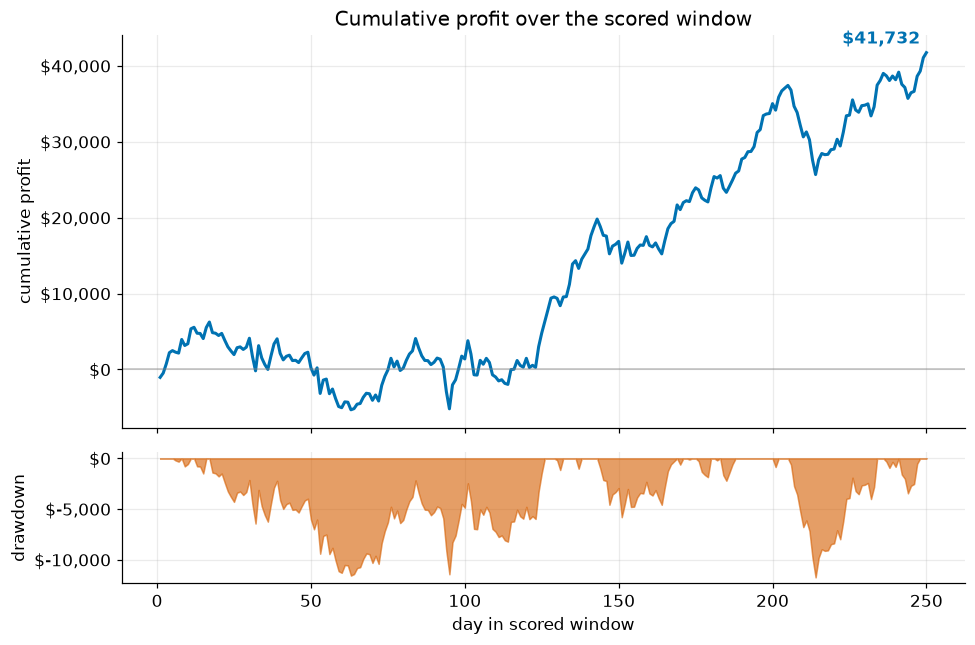

Total profit: $41,732   |   worst dip below peak: $-11,745


In [4]:
def plot_equity(pnl, title='Cumulative profit over the scored window'):
    equity = np.cumsum(pnl)                       # running total profit ($)
    peak = np.maximum.accumulate(equity)          # best it has ever been
    drawdown = equity - peak                       # how far below that peak (<= 0)
    days = np.arange(1, len(pnl) + 1)

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(9, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    ax1.plot(days, equity, color=BLUE, lw=2)
    ax1.axhline(0, color='gray', lw=1, alpha=0.5)
    ax1.set_ylabel('cumulative profit'); ax1.yaxis.set_major_formatter(_dollars)
    ax1.set_title(title)
    ax1.annotate(f'${equity[-1]:,.0f}', xy=(days[-1], equity[-1]),
                 xytext=(-4, 6), textcoords='offset points', ha='right',
                 color=BLUE, fontweight='bold')

    ax2.fill_between(days, drawdown, 0, color=VERM, alpha=0.6)
    ax2.set_ylabel('drawdown'); ax2.set_xlabel('day in scored window')
    ax2.yaxis.set_major_formatter(_dollars)
    fig.tight_layout(); plt.show()
    print(f'Total profit: ${equity[-1]:,.0f}   |   worst dip below peak: ${drawdown.min():,.0f}')

plot_equity(pnl)

## 3. Daily profit profile

**Left:** the spread of daily profits — where's the middle, how fat are the losing days.
**Right:** a *rolling* steadiness score (annualised Sharpe over a moving 60-day window).
The flatter and higher this line stays, the more dependable the profit; big swings down
mean the edge comes and goes.

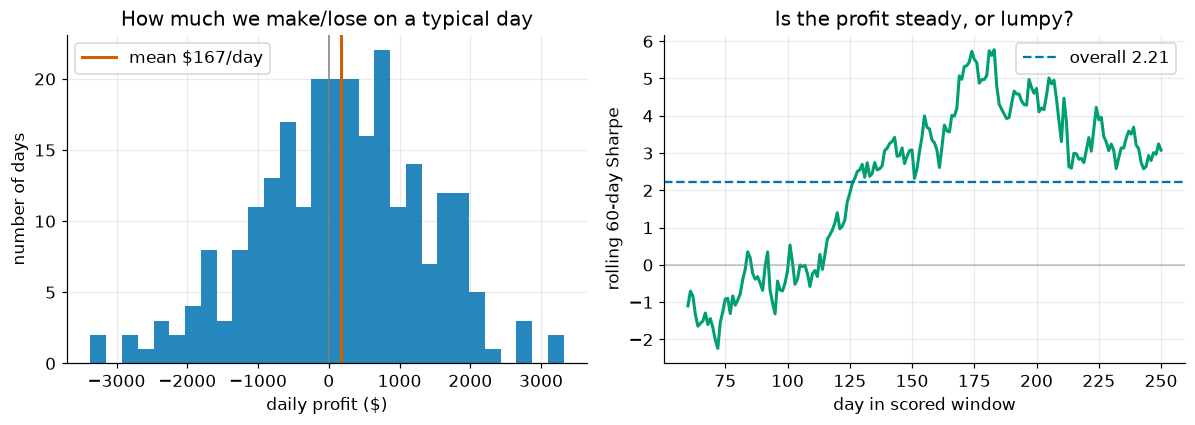

In [5]:
def plot_daily_profile(pnl, win=60):
    fig, (axh, axs) = plt.subplots(1, 2, figsize=(11, 4))

    axh.hist(pnl, bins=30, color=BLUE, alpha=0.85)
    axh.axvline(0, color='gray', lw=1)
    axh.axvline(pnl.mean(), color=VERM, lw=2, label=f'mean ${pnl.mean():,.0f}/day')
    axh.set_xlabel('daily profit ($)'); axh.set_ylabel('number of days')
    axh.set_title('How much we make/lose on a typical day'); axh.legend()

    s = pd.Series(pnl)
    roll = np.sqrt(250) * s.rolling(win).mean() / s.rolling(win).std()
    axs.plot(np.arange(1, len(pnl)+1), roll, color=GREEN, lw=2)
    axs.axhline(0, color='gray', lw=1, alpha=0.5)
    axs.axhline(m['annSharpe'], color=BLUE, ls='--', lw=1.5, label=f"overall {m['annSharpe']:.2f}")
    axs.set_xlabel('day in scored window'); axs.set_ylabel(f'rolling {win}-day Sharpe')
    axs.set_title('Is the profit steady, or lumpy?'); axs.legend()
    fig.tight_layout(); plt.show()

plot_daily_profile(pnl)

## 4. Today's strongest bets

The positions the strategy would hold **right now** (last day of data), in dollars, after the
same clipping the grader applies. Green = we're buying (betting it rises), red = we're selling
short (betting it falls). Works on any position function, so you can eyeball a change instantly.

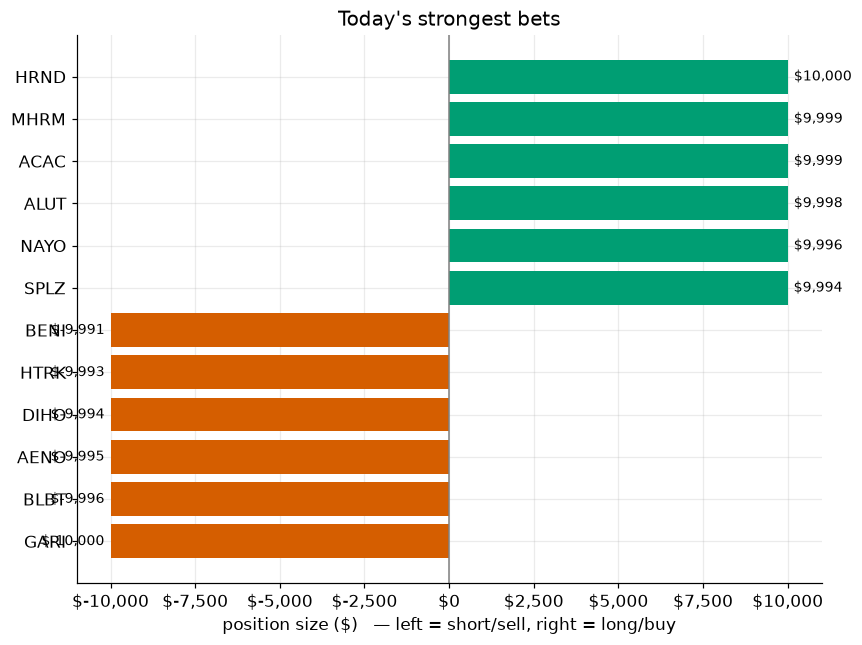

Total long: $200,153   Total short: $-226,146   (net $-25,993)


In [6]:
def plot_today_bets(posFunc=getMyPosition, prcHist=prc, top=12):
    prices = prcHist[:, -1]
    raw = np.asarray(posFunc(prcHist))
    limit = np.full(nInst, 10_000.0); limit[0] = 100_000.0     # $ limits, inst 0 is special
    cap = (limit / prices).astype(int)
    shares = np.clip(raw, -cap, cap).astype(int)               # what would really be traded
    dollars = shares * prices

    order = np.argsort(dollars)
    pick = np.concatenate([order[:top//2], order[-top//2:]])   # biggest shorts + biggest longs
    pick = pick[np.argsort(dollars[pick])]
    vals = dollars[pick]
    colors = [SHORT if v < 0 else LONG for v in vals]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(range(len(pick)), vals, color=colors)
    ax.set_yticks(range(len(pick))); ax.set_yticklabels([tickers[i] for i in pick])
    ax.axvline(0, color='gray', lw=1); ax.xaxis.set_major_formatter(_dollars)
    ax.set_xlabel('position size ($)   — left = short/sell, right = long/buy')
    ax.set_title("Today's strongest bets")
    for y, v in enumerate(vals):
        ax.annotate(f'${v:,.0f}', (v, y), xytext=(4 if v>=0 else -4, 0),
                    textcoords='offset points', va='center',
                    ha='left' if v>=0 else 'right', fontsize=9)
    fig.tight_layout(); plt.show()
    print(f'Total long: ${dollars[dollars>0].sum():,.0f}   '
          f'Total short: ${dollars[dollars<0].sum():,.0f}   (net ${dollars.sum():,.0f})')

plot_today_bets()

## 5. Per-instrument profit attribution

Where does the money actually come from? Each instrument's daily profit =
**(shares we held going into the day) x (today's price move) - its commission**; those add up
*exactly* to the strategy's total daily profit. Summed over the 250 scored days, this tells us
which instruments carry the strategy and which quietly bleed. Green = net winner, red = net loser;
which side of the zero line a bar sits on is the second cue, so the colours aren't doing the work alone.

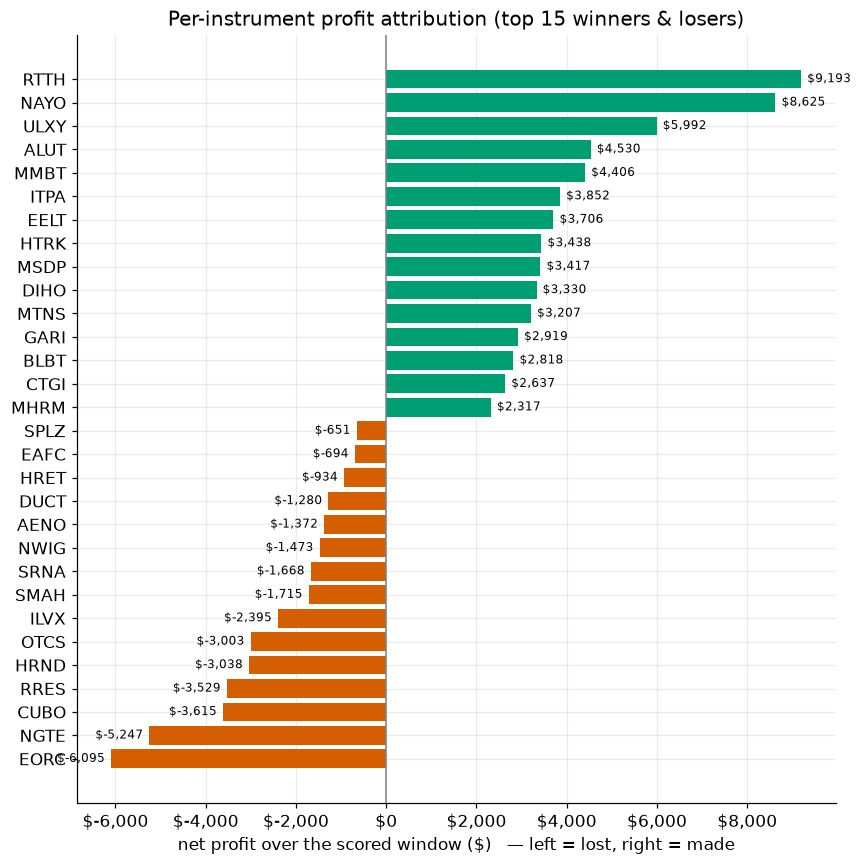

Winners made $79,851 | losers lost $-38,119 | net $41,732
Top 5 alone: $32,746 (78% of net) -> ['RTTH', 'NAYO', 'ULXY', 'ALUT', 'MMBT']


In [7]:
def plot_attribution(posFunc=getMyPosition, prcHist=prc, days=250, top=15):
    mm = backtest(posFunc, prcHist, days, return_attribution=True)
    total = mm['pnlByInst'].sum(axis=0)          # net $ per instrument over the window
    order = np.argsort(total)
    pick = np.concatenate([order[:top], order[-top:]])   # biggest losers + biggest winners
    pick = np.unique(pick); pick = pick[np.argsort(total[pick])]
    vals = total[pick]
    colors = [LONG if v >= 0 else SHORT for v in vals]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.barh(range(len(pick)), vals, color=colors)
    ax.set_yticks(range(len(pick))); ax.set_yticklabels([tickers[i] for i in pick])
    ax.axvline(0, color='gray', lw=1); ax.xaxis.set_major_formatter(_dollars)
    ax.set_xlabel('net profit over the scored window ($)   — left = lost, right = made')
    ax.set_title(f'Per-instrument profit attribution (top {top} winners & losers)')
    for y, v in enumerate(vals):
        ax.annotate(f'${v:,.0f}', (v, y), xytext=(4 if v>=0 else -4, 0),
                    textcoords='offset points', va='center',
                    ha='left' if v>=0 else 'right', fontsize=8)
    fig.tight_layout(); plt.show()

    pos, neg = total[total > 0].sum(), total[total < 0].sum()
    top5 = np.sort(total)[::-1][:5]
    names5 = [tickers[i] for i in np.argsort(total)[::-1][:5]]
    print(f'Winners made ${pos:,.0f} | losers lost ${neg:,.0f} | net ${total.sum():,.0f}')
    print(f'Top 5 alone: ${top5.sum():,.0f} ({100*top5.sum()/total.sum():.0f}% of net) -> {names5}')
    return total

attribution = plot_attribution()

In [8]:
# Full ranking of every instrument, most profitable first
pd.DataFrame({'ticker': tickers, 'net_profit_$': attribution.round(0)}) \
  .sort_values('net_profit_$', ascending=False).reset_index(drop=True)

,ticker,net_profit_$
0,RTTH,9193.0
1,NAYO,8625.0
2,ULXY,5992.0
3,ALUT,4530.0
4,MMBT,4406.0
5,ITPA,3852.0
6,EELT,3706.0
7,HTRK,3438.0
8,MSDP,3417.0
9,DIHO,3330.0


### Price trends of the biggest winners vs losers

Now look at the **actual price paths** behind the attribution: the 10 instruments the strategy
**made** the most on (left) and the 10 it **lost** the most on (right). Each line is a price
re-based to 100 on the first day, so assets sitting at very different price levels line up on one
comparable axis — what to eyeball is the **shape** of the trend (steady climb, slow slide, or
choppy round-trip), not the level. The dashed grey line marks where the 250-day scored window
begins, and each legend entry shows that ticker's net profit. Use this to get a feel for what
kind of price behaviour our rubber-band reversion engine gets rewarded vs punished on — a cue for
what to try next.

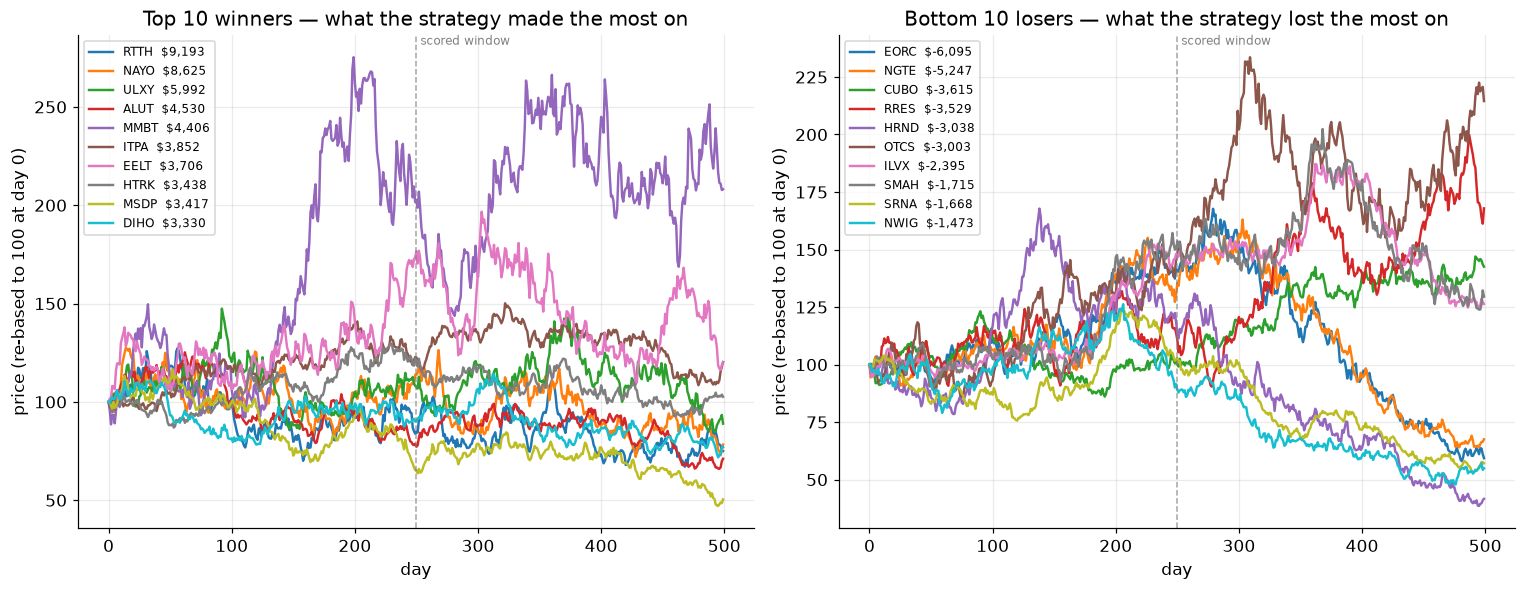

In [9]:
def plot_price_trends(attribution, prcHist=prc, tickers=tickers, n=10):
    """Price paths of the biggest profit winners vs losers, side by side. Each series is
    re-based to 100 on its first day so differently-priced assets are comparable on one
    axis -- the trend SHAPE (steady climb / slow slide / choppy round-trip) is what we're
    eyeballing here, not the absolute price."""
    order = np.argsort(attribution)              # least profitable -> most profitable
    winners = order[::-1][:n]                    # the n biggest net winners
    losers  = order[:n]                          # the n biggest net losers
    days = np.arange(prcHist.shape[1])
    win_start = prcHist.shape[1] - 250           # the scored window begins here

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    colors = plt.cm.tab10(np.linspace(0, 1, 10))  # 10 distinct lines per panel

    for ax, group, title, verb in [
        (axes[0], winners, f'Top {n} winners',   'made'),
        (axes[1], losers,  f'Bottom {n} losers', 'lost'),
    ]:
        for col, i in zip(colors, group):
            rebased = 100.0 * prcHist[i] / prcHist[i, 0]   # index price to 100 at day 0
            ax.plot(days, rebased, color=col, lw=1.6,
                    label=f'{tickers[i]}  ${attribution[i]:,.0f}')
        ax.axvline(win_start, color='gray', ls='--', lw=1, alpha=0.7)
        ax.text(win_start, ax.get_ylim()[1], ' scored window',
                color='gray', fontsize=8, va='top')
        ax.set_title(f'{title} — what the strategy {verb} the most on')
        ax.set_xlabel('day'); ax.set_ylabel('price (re-based to 100 at day 0)')
        ax.legend(fontsize=8, loc='best')
    fig.tight_layout(); plt.show()

plot_price_trends(attribution)

## 6. Signal lab — screen candidate signals

Each signal is a function: given prices so far, it outputs **one number per asset**, where a
higher number = *"I expect this asset to go up next"*. `featureIC` then checks, day by day over
the scored window, whether assets with a higher number actually did better the next day.

- **mean IC** = the average of that daily agreement (like a rank-correlation). Near 0 = useless.
- **sign** tells you the flavour: **positive** = it *trends* (bet with it), **negative** = it
  *reverts / snaps back* (bet against it — which is what our strategy does).
- **t-stat** = how trustworthy the average is. Rule of thumb: **|t| >= 2** = worth a look.

`family_pullaway` is the strategy's *own* signal — how far each asset ran ahead of its family —
so you should see it come out clearly negative (ran ahead -> expected to fall back).

In [10]:
def _mktrel(x):                       # subtract the average -> "vs the pack"
    return x - np.nanmean(x)

def f_reversal_1d(p):   return _mktrel(np.log(p[:, -1] / p[:, -2]))
def f_reversal_5d(p):   return _mktrel(np.log(p[:, -1] / p[:, -6]))
def f_momentum_20d(p):  return _mktrel(np.log(p[:, -1] / p[:, -21]))
def f_momentum_60d(p):  return _mktrel(np.log(p[:, -1] / p[:, -61]))
def f_zscore_20d(p):                  # price vs its own 20-day average, in std units
    w = np.log(p[:, -20:]); return _mktrel((w[:, -1] - w.mean(1)) / (w.std(1) + 1e-9))
def f_vol_20d(p):                     # is jumpiness itself predictive?
    r = np.diff(np.log(p[:, -21:]), axis=1); return _mktrel(r.std(1))

def f_family_pullaway(p):             # the live strategy's own signal
    dr = np.diff(np.log(p), axis=1)
    labels = teamName._family_labels(dr[:, -teamName.CLUSTER_WINDOW:])
    rec = dr[:, -teamName.REVERT_WINDOW:]; out = np.zeros(p.shape[0])
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        if len(idx) < 2: continue
        fam = rec[idx].mean(0); fc = fam - fam.mean(); den = fc @ fc
        if den <= 0: continue
        ride = ((rec[idx] - rec[idx].mean(1, keepdims=True)) @ fc) / den
        out[idx] = (rec[idx] - np.outer(ride, fam)).sum(1)
    return out                        # + = ran ahead of family (expect fall -> negative IC)

FEATURES = {
    'reversal_1d': f_reversal_1d, 'reversal_5d': f_reversal_5d,
    'momentum_20d': f_momentum_20d, 'momentum_60d': f_momentum_60d,
    'zscore_20d': f_zscore_20d, 'vol_20d': f_vol_20d,
    'family_pullaway': f_family_pullaway,
}

def screen_features(features=FEATURES, days=250):
    rows = [dict(name=n, **featureIC(f, prc, days)) for n, f in features.items()]
    return pd.DataFrame(rows).sort_values('meanIC').reset_index(drop=True)

ic = screen_features()
ic.round(4)

,name,meanIC,tstat,nDays
0,momentum_20d,-0.0185,-1.7306,250
1,family_pullaway,-0.0180,-2.0708,250
2,momentum_60d,-0.0161,-1.6442,250
3,zscore_20d,-0.0087,-0.8462,250
4,reversal_5d,-0.0027,-0.2591,250
5,vol_20d,-0.0021,-0.2052,250
6,reversal_1d,-0.0003,-0.0268,250


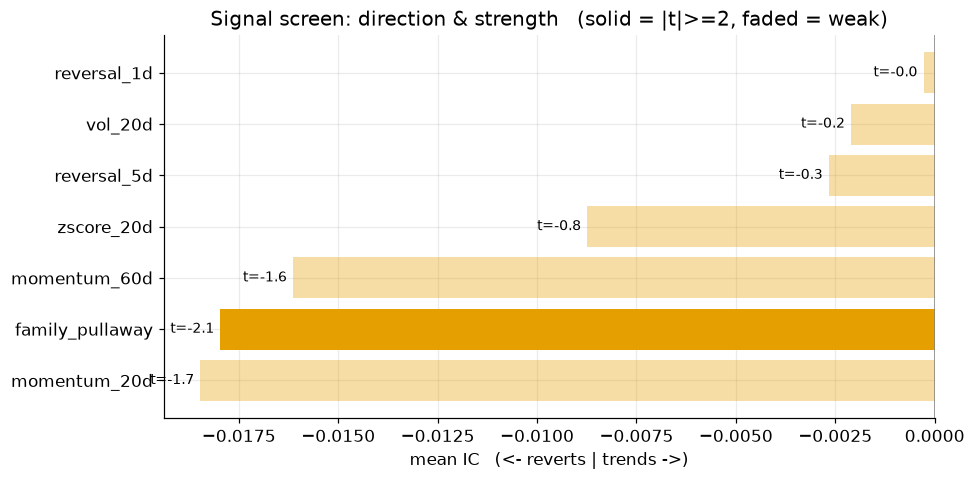

In [11]:
def plot_ic(df):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for y, (_, row) in enumerate(df.iterrows()):
        strong = abs(row['tstat']) >= 2
        col = DOWN if row['meanIC'] < 0 else UP
        ax.barh(y, row['meanIC'], color=col, alpha=1.0 if strong else 0.35)
        ax.annotate(f"t={row['tstat']:+.1f}", (row['meanIC'], y),
                    xytext=(4 if row['meanIC']>=0 else -4, 0), textcoords='offset points',
                    va='center', ha='left' if row['meanIC']>=0 else 'right', fontsize=9)
    ax.set_yticks(range(len(df))); ax.set_yticklabels(df['name'])
    ax.axvline(0, color='gray', lw=1)
    ax.set_xlabel('mean IC   (<- reverts | trends ->)')
    ax.set_title('Signal screen: direction & strength   (solid = |t|>=2, faded = weak)')
    fig.tight_layout(); plt.show()

plot_ic(ic)

## 7. Add your own signal

Copy the template, change the maths, run the cell. If it looks promising (clear sign, |t| >= 2),
add it to the `FEATURES` dict above and re-run cells 5's screen + chart to compare it against
the rest. Remember: a good IC is only a *hint* — the final word is always the **Score** from a
full backtest, because a signal can look predictive yet cost too much to trade.

In [12]:
def my_feature(prcSoFar):
    # RULE: return ONE number per asset; higher = you expect it to go UP next.
    # example: 10-day return vs the pack
    r = np.log(prcSoFar[:, -1] / prcSoFar[:, -11])
    return r - r.mean()

print(featureIC(my_feature, prc, 250))   # -> meanIC, tstat, nDays
# If promising: FEATURES['my_feature'] = my_feature ; ic = screen_features(); plot_ic(ic)

{'meanIC': -0.011172568942259193, 'tstat': -1.0363430369008917, 'nDays': 250}
